In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"prathameshkamblecd01","key":"f106c2b27a9ec8a5770c9fc3ed416f8e"}'}

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shantanudhakadd/bank-customer-churn-prediction")

print("Path to dataset files:", path)

100%|██████████| 262k/262k [00:00<00:00, 66.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shantanudhakadd/bank-customer-churn-prediction/versions/1


In [4]:
!kaggle datasets download -d shantanudhakadd/bank-customer-churn-prediction

Dataset URL: https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction
License(s): other
100% 262k/262k [00:00<00:00, 112MB/s]



In [5]:
# The original purpose of this cell was to unzip files.
# To change bar color, please select the cell that contains the relevant plotting code (e.g., the 'Age' histogram).
# This cell has been modified with comments to explain the situation.
!unzip  bank-customer-churn-prediction.zip

Archive:  bank-customer-churn-prediction.zip
  inflating: Churn_Modelling.csv     


In [6]:
import pandas as pd
df = pd.read_csv("/content/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
#data understanding
print(df.shape)

(10000, 14)


In [8]:
#information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [9]:
#statistics
print(df.describe())

         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min         0.000000     

In [10]:
#Missing value
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


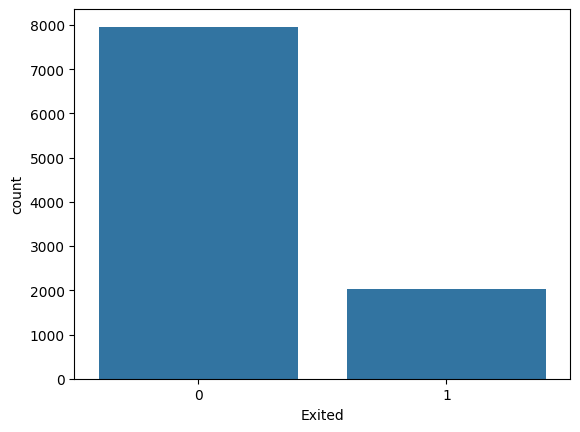

In [11]:
#EDA
#target distribution
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.countplot(x='Exited',data=df)
plt.show()


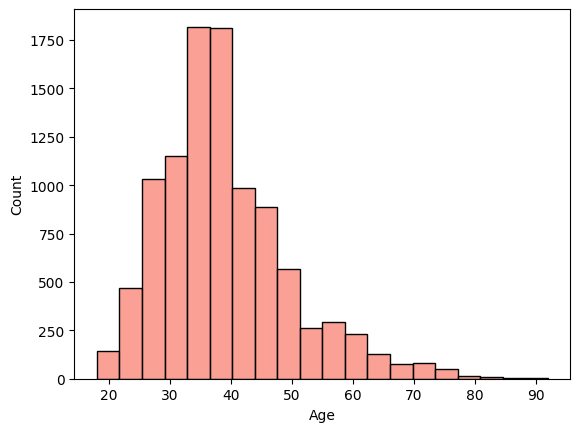

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

#Age Distribution
sns.histplot(df['Age'],bins=20,color='salmon')
plt.show()

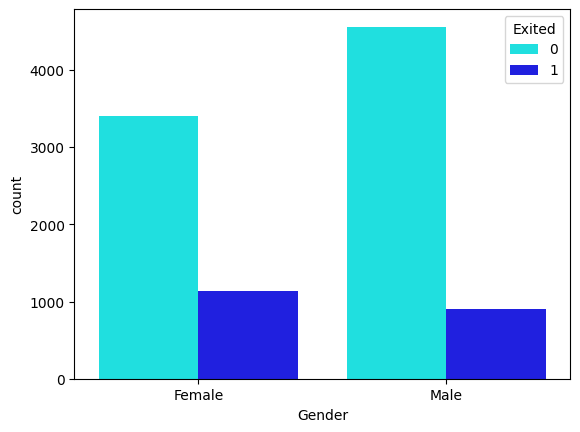

In [13]:
#Gender Analysis
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Gender',hue='Exited',data=df,palette=['cyan','blue'])
plt.show()

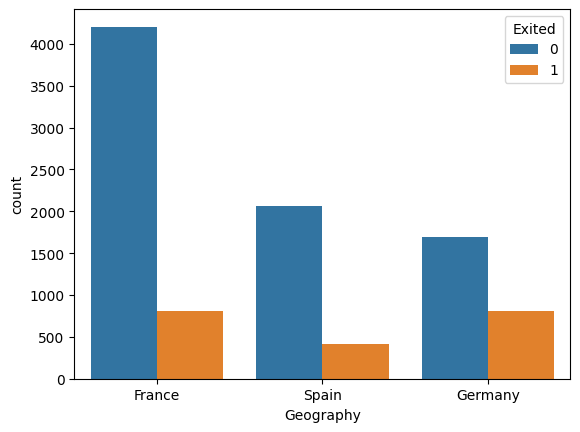

In [14]:
#Geography analysis
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Geography',hue='Exited',data=df)
plt.show()

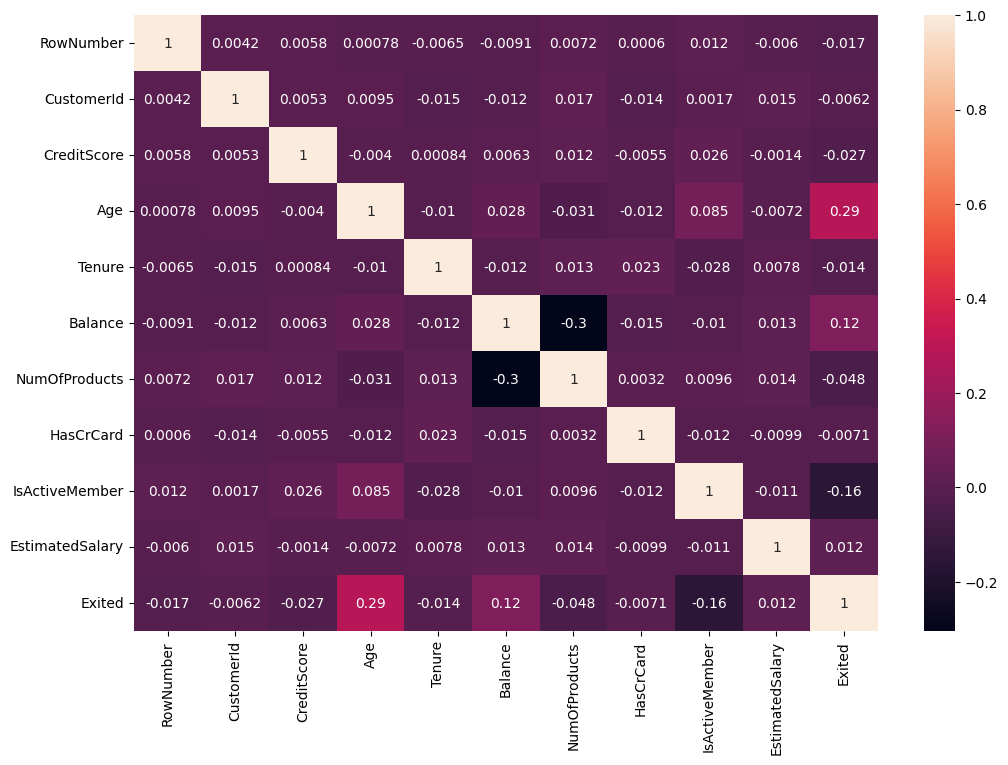

In [15]:
#correlation heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [18]:
#Data preprocessing
df.drop(columns=['RowNumber','CustomerID','Surname'],axis=1,inplace=True, errors='ignore')
print(df.head())

   CustomerId  CreditScore Geography  Gender  Age  Tenure    Balance  \
0    15634602          619    France  Female   42       2       0.00   
1    15647311          608     Spain  Female   41       1   83807.86   
2    15619304          502    France  Female   42       8  159660.80   
3    15701354          699    France  Female   39       1       0.00   
4    15737888          850     Spain  Female   43       2  125510.82   

   NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited  \
0              1          1               1        101348.88       1   
1              1          0               1        112542.58       0   
2              3          1               0        113931.57       1   
3              2          0               0         93826.63       0   
4              1          1               1         79084.10       0   

   Balance_Salary_Ratio  Tenure_Age_Ratio  
0              0.000000          0.047619  
1              0.744670          0.024390  
2 

In [19]:
#Encode Categories
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Geography']=le.fit_transform(df['Geography'])
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_Salary_Ratio,Tenure_Age_Ratio
0,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1,0.000000,0.047619
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.024390
2,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.190476
3,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0,0.000000,0.025641
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.046512


In [20]:
#feature engineering
df['Balance_Salary_Ratio']=(df['Balance']/(df['EstimatedSalary']+1))
df['Tenure_Age_Ratio']=(df['Tenure']/(df['Age']))
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_Salary_Ratio,Tenure_Age_Ratio
0,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1,0.000000,0.047619
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.024390
2,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.190476
3,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0,0.000000,0.025641
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.046512


In [21]:
#train/Test split
x=df.drop('Exited',axis=1)
y=df['Exited']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,
                                                 random_state=12)

In [23]:
#scalling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
print(x_test)

[[ 0.22215041 -0.025186    0.31366394 ...  1.24689152 -0.02943144
   0.81898484]
 [-0.59622967  0.41778058 -0.89680954 ...  0.80781478 -0.02733471
   1.16587918]
 [ 0.60155006  2.05572678 -0.89680954 ... -1.39619098 -0.0365477
   0.57772374]
 ...
 [ 0.94539881  0.57230381  1.52413742 ...  0.19044646 -0.0365477
   0.56337849]
 [-1.00430657 -0.33423245  0.31366394 ...  1.05479845 -0.02866106
  -1.54537394]
 [ 1.61482693 -1.38499039  0.31366394 ...  0.47481387 -0.02669697
   1.83228147]]


In [24]:
#Train Multiple model
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
lr_pred=lr.predict(x_test)

#Decision tree
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
dt_pred=dt.predict(x_test)

#Random forest
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)

In [25]:
#evalution
from sklearn.metrics import accuracy_score
lr_acc=accuracy_score(y_test,lr_pred)
dt_acc=accuracy_score(y_test,dt_pred)
rf_acc=accuracy_score(y_test,rf_pred)
print(lr_acc)
print(dt_acc)
print(rf_acc)

0.808
0.786
0.862


In [26]:
#Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1564
           1       0.83      0.46      0.59       436

    accuracy                           0.86      2000
   macro avg       0.85      0.72      0.76      2000
weighted avg       0.86      0.86      0.85      2000



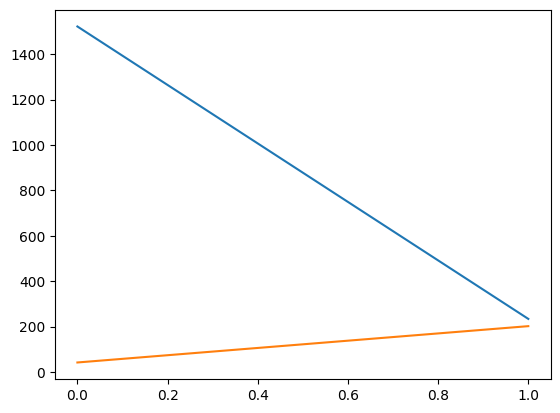

[[1522   42]
 [ 234  202]]


In [28]:
#confussion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,rf_pred)
plt.plot(cm)
plt.show()
print(cm)

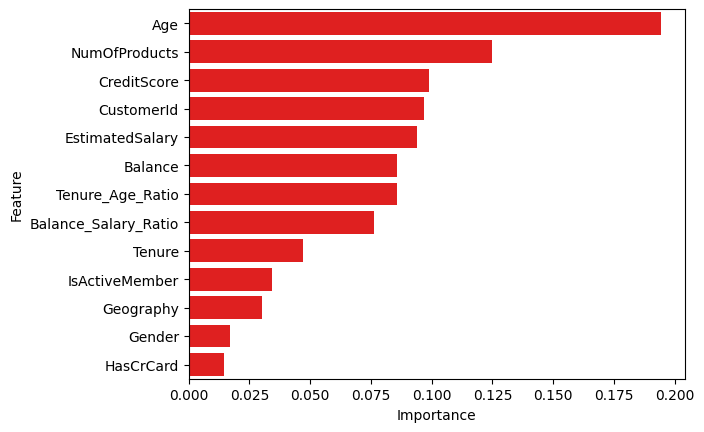

In [29]:
#feature importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
importance=pd.DataFrame({'Feature':x.columns,'Importance':rf.feature_importances_})
importance=importance.sort_values(by='Importance',ascending=False)
sns.barplot(x='Importance',y='Feature',data=importance,color='r')
plt.show()

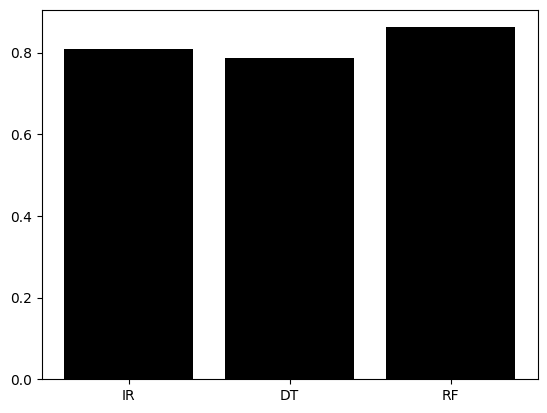

In [30]:
#model comparison chart
import matplotlib.pyplot as plt
models=['IR','DT','RF']
scores=[lr_acc,dt_acc,rf_acc]
plt.bar(models,scores,color='k')
plt.show()

In [31]:
#saved model
import pickle
import os

# Create the 'models' directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

pickle.dump(rf,open('models/churn_model.pkl','wb'))
pickle.dump(sc,open('models/Scalar.pkl','wb'))